# 02 - Prediction intra-instrument

## Data : Corn NIR (Cargill / Eigenvector)

**Question centrale** : peut-on prédire la composition du maïs à partir de spectres NIR, et conserver la
performance lorsqu'on change de spectromètre ?

Ce notebook construit et valide les modèles sur un seul instrument (m5) : PLSR, comparaison empirique de 7 prétraitements, interprétabilité (VIP, Elastic Net), et comparaison à des modèles ML.

Le transfert inter-instruments (`m5` -> `mp5`/`mp6`) est dans `03_transfert_inter_instruments.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from corn_nir.data import load_corn_mat
from corn_nir.visualization import (
    plot_spectra_overlay,
    plot_target_distributions,
    plot_nbs_standards,
    plot_pca_by_instrument,
    plot_difference_curves,
    plot_target_correlation_matrix,
    plot_pls_scores_by_target,
)

# Importation des données 

In [2]:
dataset = load_corn_mat(ROOT / "data" / "raw" / "corn.mat")
print({k: v.shape for k, v in dataset.spectra.items()})
print(dataset.targets.shape, dataset.target_names)
print({k: v.shape for k, v in dataset.nbs.items()})

{'m5': (80, 700), 'mp5': (80, 700), 'mp6': (80, 700)}
(80, 4) ['Moisture', 'Oil', 'Protein', 'Starch']
{'m5': (3, 700), 'mp5': (4, 700), 'mp6': (4, 700)}


## Partie C - Baseline PLSR sur m5

Point de départ : prétraitement **`Detrend`, appliqué après coupure à 1450 nm** (voir `01_audit_eda.ipynb`)

**Protocole : validation croisée leave-one-out (LOO) imbriquée.** Avec seulement 80 échantillons, réserver un jeu de test séparé laisserait trop peu d'échantillons pour calibrer un modèle à plusieurs centaines de variables très colinéaires, et un seul split aurait une variance d'estimation élevée. La LOO utilise chaque échantillon comme validation exactement une fois, tout en entraînant sur les 79 autres à chaque itération. Le nombre de composantes est choisi par une validation croisée **interne** à chacune des 80 itérations (règle du 1-écart-type, `select_n_components_by_cv`) : l'échantillon laissé de côté n'influence jamais ce choix, seul le résidu qu'il produit une fois prédit compte pour le résultat final (`nested_loo_plsr`, `src/corn_nir/validation.py`).

In [3]:
import pandas as pd
from corn_nir.preprocessing import CropWavelengths, Detrend

pd.set_option("display.width", 160)
RESULTS_DIR = ROOT / "reports" / "results"
FIGURES_DIR = ROOT / "reports" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

crop_mask = dataset.wavelength_nm >= 1450
wavelength_cropped = dataset.wavelength_nm[crop_mask]
X_cropped = dataset.spectra["m5"][:, crop_mask]

detrend = Detrend(wavelength_nm=wavelength_cropped, degree=1)
X_detrend = detrend.fit_transform(X_cropped)
print(f"Plage retenue : {wavelength_cropped.min():.0f}-{wavelength_cropped.max():.0f} nm "
      f"({X_detrend.shape[1]} longueurs d'onde, contre {dataset.spectra['m5'].shape[1]} sur la plage complète)")

Plage retenue : 1450-2498 nm (525 longueurs d'onde, contre 700 sur la plage complète)


**Choix du nombre de composantes latentes**


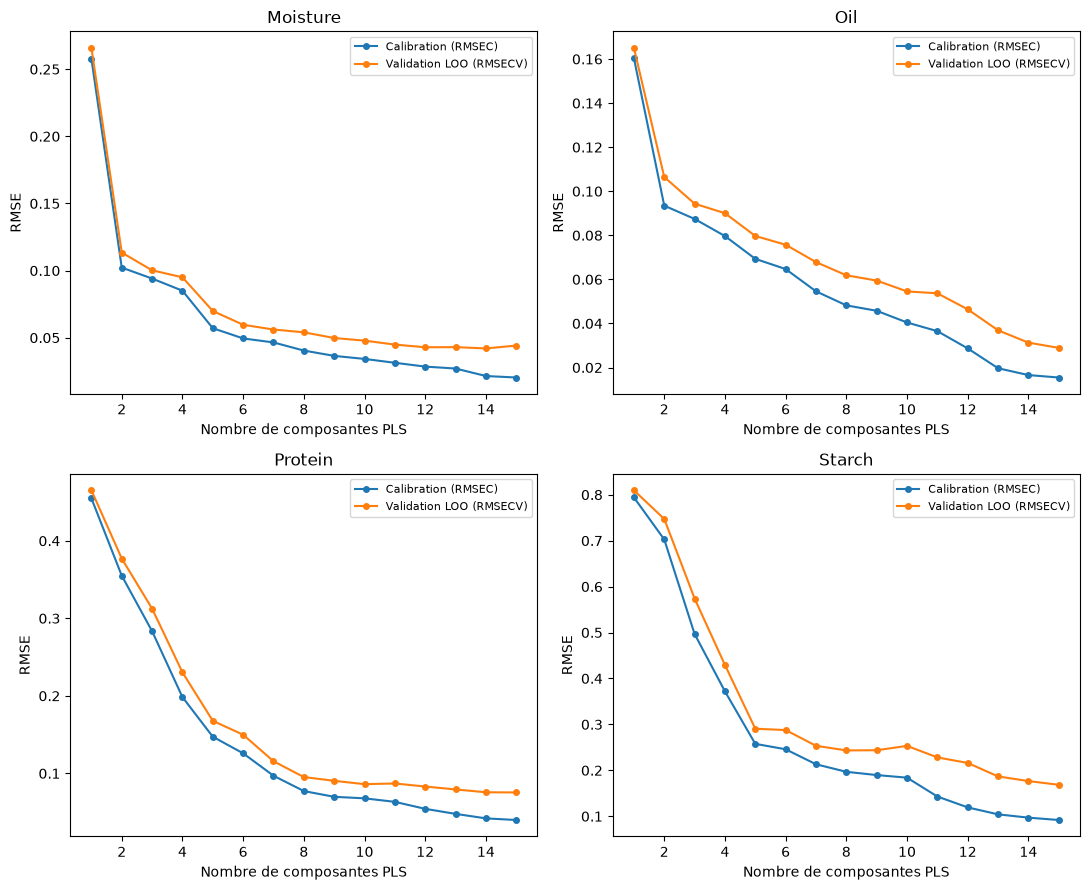

In [4]:
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from corn_nir.validation import compute_calibration_vs_loocv_curve
from corn_nir.visualization import plot_calibration_vs_loocv_curve

def pls_factory(n_components):
    return PLSRegression(n_components=n_components, scale=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
curves = {}
for ax, target in zip(axes.flat, dataset.targets.columns):
    y = dataset.targets[target].values
    rmse_cal, rmse_loocv = compute_calibration_vs_loocv_curve(
        X_detrend, y, max_components=15, pipeline_factory=pls_factory,
    )
    curves[target] = (rmse_cal, rmse_loocv)
    plot_calibration_vs_loocv_curve(rmse_cal, rmse_loocv, ax=ax, title=target)
fig.tight_layout()

Pour Moisture, la courbe RMSECV atteint un minimum vers 14 composantes puis remonte légèrement à 15. Pour Oil, Protein et Starch, elle continue de descendre jusqu'au plafond testé (15) sans se stabiliser clairement : le même phénomène déjà documenté dans ce projet (voir `select_n_components_by_cv`) : avec 525 canaux très colinéaires et 80 échantillons, la courbe ne plafonne pas naturellement, elle continue de suivre le plafond imposé. D'où le choix d'un plafond externe plutôt qu'un coude lu sur la courbe : 10, cohérent avec l'heuristique d'au moins 10 échantillons par dimension du modèle et avec la littérature sur ce même jeu de données.

Cette courbe est **non imbriquée** (le nombre de composantes choisi en la regardant verrait les 80 mêmes résidus qu'elle rapporte) : utile pour visualiser sa forme, pas comme chiffre final. Le résultat retenu ci-dessous vient du protocole imbriqué : nombre de composantes choisi sur 79 échantillons seulement, honnête par construction.


### Résultat : validation croisée leave-one-out imbriquée

In [5]:
import time
from sklearn.pipeline import Pipeline
from corn_nir.experiments import run_baseline_plsr_loo

def crop_detrend_pls_factory(n_components):
    return Pipeline([
        ("crop", CropWavelengths(wavelength_nm=dataset.wavelength_nm, crop_min_nm=1450)),
        ("detrend", Detrend(wavelength_nm=wavelength_cropped, degree=1)),
        ("plsr", PLSRegression(n_components=n_components, scale=False)),
    ])

t0 = time.time()
loo_all, baseline_summary = run_baseline_plsr_loo(
    dataset, max_components=10, inner_splits=5, random_state=0, verbose=False,
    pipeline_factory=crop_detrend_pls_factory,
)
print(f"Ran in {time.time() - t0:.1f}s")
baseline_summary.to_csv(RESULTS_DIR / "phase_c_baseline_plsr_summary.csv", index=False)
baseline_summary[[
    "target", "RMSE", "MAE", "R2", "RPD",
    "n_components_selected_mode", "n_components_selected_min", "n_components_selected_max",
]].round(4)

Ran in 105.7s


,target,RMSE,MAE,R2,RPD,n_components_selected_mode,n_components_selected_min,n_components_selected_max
0,Moisture,0.0491,0.0378,0.9831,7.7409,9,8,10
1,Oil,0.0610,0.0469,0.8796,2.9005,10,8,10
2,Protein,0.0901,0.0687,0.9670,5.5362,9,8,9
3,Starch,0.2650,0.2145,0.8944,3.0966,7,6,10


Moisture (RMSE=0.049, R2=0.983, RPD=7.74), Protein (RMSE=0.090, R2=0.967, RPD=5.54) et Oil (RMSE=0.061, R2=0.880, RPD=2.90) restent nettement au-dessus du seuil usuel de RPD=2 pour un modèle exploitable ; Starch (RMSE=0.265, R2=0.894, RPD=3.10) aussi, dans une moindre mesure. Le nombre de composantes choisi varie peu entre les 80 iterations (Moisture: mode 9, plage [8,10] ; Protein: mode 9, plage [8,9] ; Oil: mode 10, plage [8,10]). Starch est la cible la moins stable sur ce point (mode 7, plage [6,10]).

**Exception attendue, pas une anomalie : Moisture.** `raw` (Partie D plus bas) fait *mieux* que ce point de départ pour Moisture (RMSE 0.019 vs 0.049), cohérent avec l'étape 3 du diagnostic de l'EDA : pour cette cible spécifiquement, le signal utile loge en bonne partie dans le niveau/l'échelle du spectre, exactement ce que `Detrend` retire. `raw`, testé comme une des 7 alternatives de la Partie D (pas comme prétraitement par défaut), l'emporte donc pour Moisture : le point de départ raisonné n'avait pas vocation à être optimal partout, seulement à être un candidat défendable a priori.

## Partie D - Comparaison de différents prétraitements

La Partie C a fixé un prétraitement de départ (`Detrend`) à partir du diagnostic ; cette partie le confronte à 6 autres variantes, **`raw` inclus**, avec le même moteur de validation croisée leave-one-out imbriquée que la Partie C (`nested_loo_plsr`) : `raw`, `mean_center`, `snv`, `msc`, `sg_smooth`, `sg_deriv1`, `sg_deriv2`. 28 combinaisons (prétraitement x cible) x 80 itérations LOO chacune, soit environ 6 minutes pour cette cellule.


In [6]:
from corn_nir.experiments import run_preprocessing_comparison_loo

t0 = time.time()
loo_all_prep, prep_, best_prep = run_preprocessing_comparison_loo(
    dataset, max_components=10, inner_splits=3, random_state=0, verbose=False,
)
print(f"Ran {len(prep_)} (preprocessing, target) combinations in {time.time() - t0:.1f}s")
prep_.pivot_table(index="preprocessing", columns="target", values="RMSE").round(4)

Ran 28 (preprocessing, target) combinations in 415.3s


target,Moisture,Oil,Protein,Starch
preprocessing,,,,
mean_center,0.0186,0.0700,0.1261,0.2666
msc,0.1424,0.0879,0.1325,0.2876
raw,0.0186,0.0700,0.1261,0.2666
sg_deriv1,0.0327,0.0424,0.0925,0.2360
sg_deriv2,0.0761,0.0300,0.1021,0.2283
sg_smooth,0.0186,0.0700,0.1260,0.2673
snv,0.1433,0.0881,0.1372,0.2768


**Constats** (protocole leave-one-out imbriqué) :
- `raw` et `mean_center` restent quasi identiques (0.0186 pour Moisture, aux arrondis près). PLSR centre déjà en interne, c'est un test de cohérence intégré (le pipeline est bien câblé), pas une vraie comparaison. La légère avance numérique de l'un ou l'autre selon la cible n'est pas significative.
- `SNV`/`MSC` **dégradent** chaque cible, le plus spectaculairement pour Moisture (x7-8). Cohérent avec le constat de la PCA en EDA (le niveau du spectre porte un vrai signal chimique ici).
- Les **dérivées** Savitzky-Golay restent la seule famille qui améliore sur `raw` pour Oil/Protein/Starch (pas pour Moisture, déjà excellent sur `raw`).


In [7]:
best_prep.to_csv(RESULTS_DIR / "phase_d_best_preprocessing_per_target.csv", index=False)
best_prep[["target", "preprocessing", "RMSE", "R2"]].round(4)

,target,preprocessing,RMSE,R2
4,Moisture,mean_center,0.0186,0.9976
25,Oil,sg_deriv2,0.0300,0.9709
22,Protein,sg_deriv1,0.0925,0.9652
27,Starch,sg_deriv2,0.2283,0.9216


## Partie E - VIP, coefficients PLS et Elastic Net

Scores VIP (Wold et al.) et une alternative de sélection parcimonieuse (Elastic Net), calculés sur le meilleur prétraitement de chaque cible (Partie D). Performance d'Elastic Net évaluée par le même protocole leave-one-out imbriqué que les Parties C/D (`run_variable_selection_loo`), avec une grille de recherche allégée (un seul l1_ratio, 10 valeurs d'alpha) pour rester exécutable en quelques minutes malgré le facteur ~80x de la LOO.


In [8]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from corn_nir.experiments import run_variable_selection_loo
from corn_nir.visualization import plot_vip

best_prep = best_prep.set_index("target")["preprocessing"].to_dict()
print(best_prep)

t0 = time.time()
result = run_variable_selection_loo(
    dataset, best_prep, max_components=10, inner_splits=5, random_state=0, verbose=False,
    enet_l1_ratio=(0.9,), enet_n_alphas=10, enet_cv=3, enet_max_iter=5000, enet_tol=1e-2,
)
print(f"Ran in {time.time() - t0:.1f}s")
result["vip_summary"].round(3)

{'Moisture': 'mean_center', 'Oil': 'sg_deriv2', 'Protein': 'sg_deriv1', 'Starch': 'sg_deriv2'}
Ran in 83.0s


,target,preprocessing,n_components,n_wavelengths_vip_above_1,fatemi_2022_band_nm,n_vip_wavelengths_inside_fatemi_band,fraction_vip_wavelengths_inside_fatemi_band
0,Moisture,mean_center,9,267,1908-2108,60,0.225
1,Oil,sg_deriv2,10,190,2176-2304,31,0.163
2,Protein,sg_deriv1,8,255,2130-2190,22,0.086
3,Starch,sg_deriv2,8,214,1452-1770,48,0.224


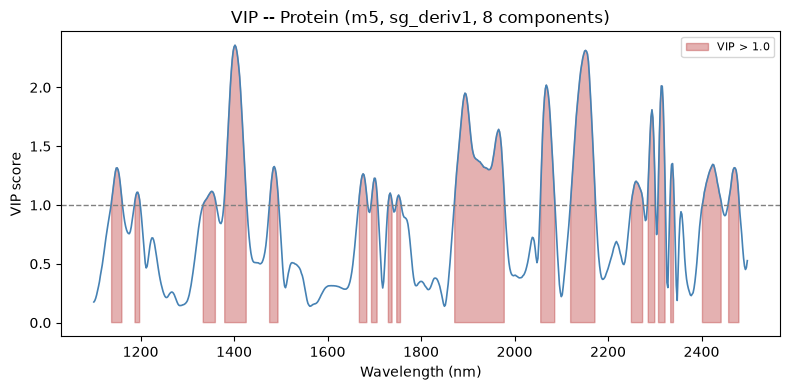

In [9]:
protein = result["per_target"]["Protein"]
fig = plot_vip(
    dataset.wavelength_nm, protein["vip"], threshold=1.0,
    title=f"VIP -- Protein (m5, {protein['preprocessing']}, {protein['n_components']} components)",
)
fig.savefig(FIGURES_DIR / "vip_protein.png", dpi=200)

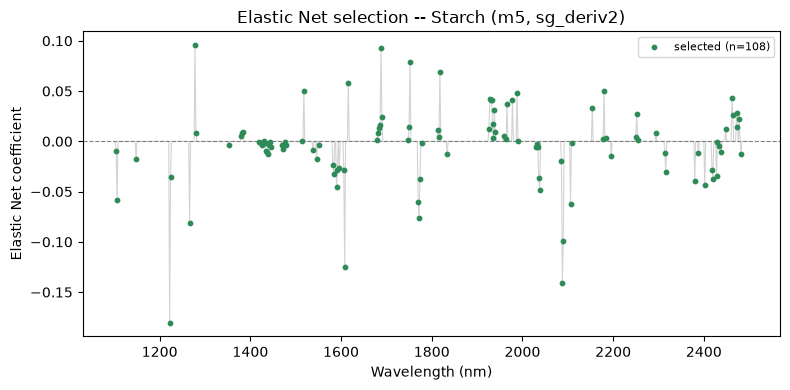

In [10]:
from corn_nir.visualization import plot_elasticnet_selection

starch = result["per_target"]["Starch"]
fig_enet = plot_elasticnet_selection(
    dataset.wavelength_nm, starch["enet_coefs"],
    title=f"Elastic Net selection -- Starch (m5, {starch['preprocessing']})",
)
fig_enet.savefig(FIGURES_DIR / "elasticnet_selection_starch.png", dpi=200)

### Comparaison à la littérature

Fatemi, Singh & Kamruzzaman (2022, *Food Chemistry* 383, 132442) rapportent des bandes informatives par propriété, vérifiées via deux sources indépendantes (Semantic Scholar, Illinois Experts). La comparaison ci-dessus (colonne `fraction_vip_wavelengths_inside_fatemi_band`) est descriptive, pas forcée : VIP>1 répond à « contribue plus que la moyenne sur tout le spectre », alors que Fatemi et al. ont utilisé VIP + un algorithme génétique pour sélectionner une région cible étroite. Un recouvrement partiel (pas total) est donc attendu. Les bandes précises rapportées par Wu et al. (2023) n'ont pas pu être vérifiées de façon indépendante depuis des sources accessibles, donc aucune comparaison chiffrée n'est faite avec cet article.


In [11]:
result["enet_summary"].to_csv(RESULTS_DIR / "phase_e_elasticnet_summary.csv", index=False)
result["enet_summary"].round(4)

,target,preprocessing,RMSE,MAE,R2,RPD,n_wavelengths_selected,alpha_selected,l1_ratio_selected
0,Moisture,mean_center,0.0617,0.0455,0.9734,6.1674,62,0.0013,0.9
1,Oil,sg_deriv2,0.0336,0.0258,0.9635,5.2685,124,0.0007,0.9
2,Protein,sg_deriv1,0.0472,0.0335,0.9909,10.5668,51,0.0045,0.9
3,Starch,sg_deriv2,0.1916,0.1503,0.9448,4.2847,108,0.0032,0.9


**Résultat notable** : sous ce protocole honnête (leave-one-out imbriqué, pas de fuite entre sélection et évaluation), Elastic Net **dépasse nettement** PLSR pour Protein (RMSE=0.047 vs 0.093, quasiment deux fois meilleur) et Starch (RMSE=0.192 vs 0.228), reste légèrement en retrait pour Oil (0.034 vs 0.030), et perd nettement pour Moisture (0.062 vs 0.019). Contrairement à ce qu'on aurait pu craindre avec un protocole plus léger (peu de folds), cet avantage pour Protein/Starch n'est pas qu'un artefact d'optimisme de validation croisée à petit n, il survit à la LOO imbriquée. Une explication plausible : la sélection parcimonieuse d'Elastic Net (51 à 124 longueurs d'onde retenues selon la cible, contre les 525-700 canaux vus par la PLS) réduit la dimensionnalité effective, ce qui peut aider quand le signal utile est concentré sur peu de bandes (Protein, Starch) mais pas quand il dépend du niveau global du spectre (Moisture).


## Partie F - Comparaison des modèles ML

Ridge, SVR-RBF, Random Forest, Gradient Boosting (`src/corn_nir/models.py`), chacun sur le meilleur prétraitement de sa cible (Partie D), évalués par le même protocole leave-one-out que les Parties C/D/E (`run_ml_comparison_loo`). Random Forest et Gradient Boosting utilisent des hyperparamètres fixes plutôt qu'une recherche interne sous LOO (voir `make_ml_pipeline_factory_loo`) : une recherche complète à chacune des 80 itérations n'aurait pas été un usage proportionné du temps de calcul pour le gain attendu à cette taille d'échantillon. Ridge et SVR-RBF gardent leur propre recherche interne. Cette cellule prend environ 10 minutes (Random Forest et Gradient Boosting restent la partie la plus lente).


In [12]:
from corn_nir.experiments import run_ml_comparison_loo
from corn_nir.validation import nested_loo_plsr
from corn_nir.evaluation import regression_metrics
from corn_nir.preprocessing import build_preprocessing

# Reference : PLSR de la Partie D, sur le meilleur pretraitement de chaque cible (pas le point de
# depart Detrend de la Partie C, qui n'a pas vocation a etre optimal partout, voir Partie C).
plsr_rows = []
for target, prep_name in best_prep.items():
    y = dataset.targets[target].values

    def factory(n_components, prep_name=prep_name):
        prep = build_preprocessing(prep_name)
        model = PLSRegression(n_components=n_components, scale=False)
        return model if prep is None else Pipeline([("prep", prep), ("plsr", model)])

    loo_df = nested_loo_plsr(
        dataset.spectra["m5"], y, max_components=10, inner_splits=3, pipeline_factory=factory,
    )
    plsr_rows.append({"target": target, **regression_metrics(loo_df["y_true"], loo_df["y_pred"])})
plsr_reference = pd.DataFrame(plsr_rows)

t0 = time.time()
loo_all_ml, ml_, ml_best = run_ml_comparison_loo(
    dataset, best_prep, inner_splits=3, random_state=0, verbose=True, plsr_reference=plsr_reference,
)
print(f"Ran in {time.time() - t0:.1f}s")

[comparaison ML, LOO] cible=Moisture : modele=ridge (pretraitement=mean_center), CV leave-one-out (80 iterations)...
    RMSE=0.007  R2=1.000  RPD=56.08
[comparaison ML, LOO] cible=Moisture : modele=svr_rbf (pretraitement=mean_center), CV leave-one-out (80 iterations)...
    RMSE=0.092  R2=0.941  RPD=4.13
[comparaison ML, LOO] cible=Moisture : modele=random_forest (pretraitement=mean_center), CV leave-one-out (80 iterations)...
    RMSE=0.256  R2=0.543  RPD=1.49
[comparaison ML, LOO] cible=Moisture : modele=gradient_boosting (pretraitement=mean_center), CV leave-one-out (80 iterations)...
    RMSE=0.256  R2=0.543  RPD=1.49
[comparaison ML, LOO] cible=Oil : modele=ridge (pretraitement=sg_deriv2), CV leave-one-out (80 iterations)...
    RMSE=0.029  R2=0.973  RPD=6.15
[comparaison ML, LOO] cible=Oil : modele=svr_rbf (pretraitement=sg_deriv2), CV leave-one-out (80 iterations)...
    RMSE=0.078  R2=0.804  RPD=2.27
[comparaison ML, LOO] cible=Oil : modele=random_forest (pretraitement=sg_deri

In [13]:
ml_.to_csv(RESULTS_DIR / "phase_f_ml_comparison_summary.csv", index=False)
ml_.pivot_table(index="model", columns="target", values="RMSE").round(4)

target,Moisture,Oil,Protein,Starch
model,,,,
gradient_boosting,0.2555,0.0983,0.2134,0.3937
plsr,0.0186,0.0300,0.0925,0.2283
random_forest,0.2556,0.1017,0.2342,0.4215
ridge,0.0068,0.0288,0.0304,0.1640
svr_rbf,0.0920,0.0779,0.1489,0.2975


**Constat** (protocole leave-one-out imbriqué) : les modèles non linéaires (SVR, Random Forest, Gradient Boosting) sous-performent systématiquement les méthodes linéaires (PLSR, Ridge) sur chaque cible, la question méthodologique centrale de la fiche projet (« les modèles non linéaires aident-ils sur 80 échantillons ? ») a ici une réponse claire : non, pas sur ce dataset. Ridge devance PLSR sur les 4 cibles (le plus nettement pour Protein : 0.030 vs 0.093, et Starch : 0.164 vs 0.228), cohérent avec le constat similaire d'Elastic Net en Partie E : une régularisation linéaire bien choisie (L2 pour Ridge, L1+L2 pour Elastic Net) semble mieux exploiter ce jeu de données que la PLS elle-même, pour ces deux cibles spécifiquement.

Une piste naturelle pour la suite serait d'essayer d'autres méthodes de sélection de variables au-delà d'Elastic Net : CovSel (sélection par covariance avec la cible, pensée pour des données spectrales colinéaires) semble la plus prometteuse dans le même esprit ; un filtre univarié type SelectKBest risque en revanche de retenir des longueurs d'onde redondantes plutôt qu'informatives, vu la forte colinéarité entre canaux voisins ; une sélection séquentielle (forward/backward) pourrait en théorie faire mieux mais demanderait la même validation en LOO imbriqué que le reste de ce notebook, pour éviter le biais d'optimisme déjà discuté en Partie C, ce qui n'est pas fait ici. Piste à explorer, pas testée dans ce notebook.


## Suite

`03_transfert_inter_instruments.ipynb` : que se passe-t-il quand la baseline entraînée sur m5 ci-dessus
est appliquée directement à `mp5`/`mp6`, et comment la Direct Standardization permet-elle de récupérer
la performance perdue ?
